<a href="https://colab.research.google.com/github/divijakalra05/ML-project/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1

In [3]:
# ============================================================
# PROBLEM 1: Environment Verification
# ============================================================

import tensorflow as tf
import matplotlib
import numpy as np
import pandas as pd
import random
import os

# ============================================================
# STEP 3: Print version of every package
# ============================================================
print("=" * 40)
print("PACKAGE VERSIONS")
print("=" * 40)
print(f"TensorFlow version : {tf.__version__}")
print(f"Matplotlib version : {matplotlib.__version__}")
print(f"NumPy version      : {np.__version__}")       # ✅ FIXED: np not numpy
print(f"Pandas version     : {pd.__version__}")
print("=" * 40)

# ============================================================
# STEP 4: Check if GPU is available
# ============================================================
gpus = tf.config.list_physical_devices('GPU')

print("\nGPU CHECK")
print("=" * 40)

if gpus:
    print(f"GPU is AVAILABLE! Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"   -> {gpu}")
else:
    print("No GPU detected. Running on CPU.")

    # WHY CPU IS SLOWER THAN GPU:
    # A CPU has very few cores (usually 4–16) → does tasks one by one.
    # A GPU has THOUSANDS of small cores → does millions of calculations at the same time.
    # CNNs need huge amounts of math on image pixels → GPU handles this much faster.
    #
    # WHAT WE WOULD DO DIFFERENTLY ON A GPU MACHINE:
    # 1. Use larger batch sizes (64 or 128) since GPU has more memory/speed.
    # 2. Train for more epochs since training would be much faster.
    # 3. Use bigger/deeper CNN models that would be too slow on CPU.

print("=" * 40)

# ============================================================
# STEP 5: Set ALL random seeds to 42
# ============================================================

random.seed(42)         # Controls: Python's random module (random.random(), random.shuffle())
np.random.seed(42)      # Controls: NumPy operations (np.random.rand(), array shuffling)
tf.random.set_seed(42)  # Controls: TensorFlow layer weights, dropout, augmentation
os.environ['PYTHONHASHSEED'] = '42'  # Controls: low-level C++ ops inside TensorFlow

print("\nRANDOM SEEDS")
print("=" * 40)
print("All random seeds set to 42!")
print("  -> random.seed(42)        : Python random module")
print("  -> np.random.seed(42)     : NumPy operations")
print("  -> tf.random.set_seed(42) : TensorFlow/Keras layers")
print("  -> PYTHONHASHSEED = 42    : Python hash operations")
print("=" * 40)

print("\nEnvironment setup COMPLETE and READY!")

PACKAGE VERSIONS
TensorFlow version : 2.19.0
Matplotlib version : 3.10.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2

GPU CHECK
No GPU detected. Running on CPU.

RANDOM SEEDS
All random seeds set to 42!
  -> random.seed(42)        : Python random module
  -> np.random.seed(42)     : NumPy operations
  -> tf.random.set_seed(42) : TensorFlow/Keras layers
  -> PYTHONHASHSEED = 42    : Python hash operations

Environment setup COMPLETE and READY!


Loading datasets...
Done!

PART (a): SHAPES
MNIST:
  Training images shape : (60000, 28, 28)
  Training labels shape : (60000,)
  Test images shape     : (10000, 28, 28)
  Test labels shape     : (10000,)

CIFAR-10:
  Training images shape : (50000, 32, 32, 3)
  Training labels shape : (50000, 1)
  Test images shape     : (10000, 32, 32, 3)
  Test labels shape     : (10000, 1)

PART (b): DATA TYPE AND PIXEL VALUE RANGE
MNIST:
  Data type  : uint8
  Min value  : 0
  Max value  : 255

CIFAR-10:
  Data type  : uint8
  Min value  : 0
  Max value  : 255

PART (c): MNIST SAMPLES PER CLASS
Class | Name | Count
------------------------------
  0   |  0   | 5923
  1   |  1   | 6742
  2   |  2   | 5958
  3   |  3   | 6131
  4   |  4   | 5842
  5   |  5   | 5421
  6   |  6   | 5918
  7   |  7   | 6265
  8   |  8   | 5851
  9   |  9   | 5949
------------------------------
Total samples: 60000
Min count: 5421
Max count: 6742

Balanced? NO ❌
  Difference between most and least frequent class = 1321


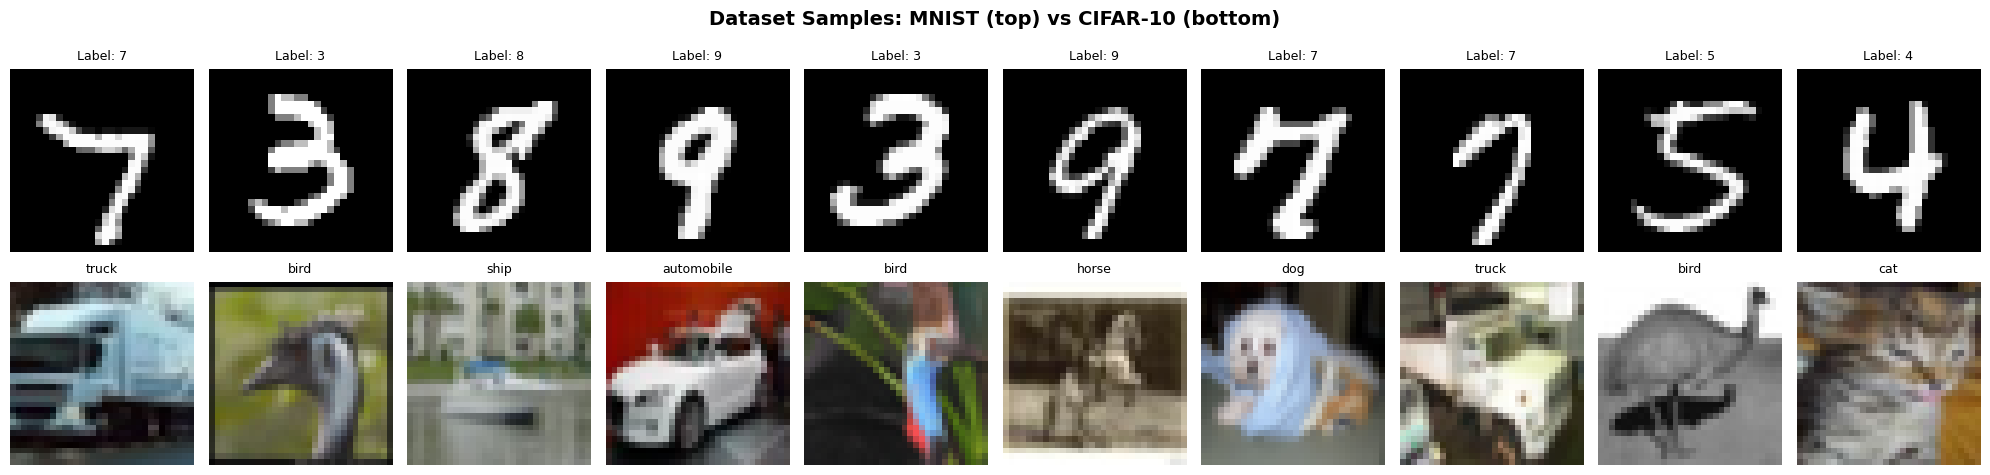

In [5]:
# ============================================================
# PROBLEM 2: Dataset Exploration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
import random

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Load both datasets
# ============================================================
print("Loading datasets...")
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()
print("Done!\n")

# ============================================================
# PART (a): Shape of training and test arrays
# ============================================================
print("=" * 45)
print("PART (a): SHAPES")
print("=" * 45)

print("MNIST:")
print(f"  Training images shape : {mnist_x_train.shape}")
print(f"  Training labels shape : {mnist_y_train.shape}")
print(f"  Test images shape     : {mnist_x_test.shape}")
print(f"  Test labels shape     : {mnist_y_test.shape}")

# Shape means: (number of images, height, width) for MNIST
# and (number of images, height, width, color channels) for CIFAR-10

print("\nCIFAR-10:")
print(f"  Training images shape : {cifar_x_train.shape}")
print(f"  Training labels shape : {cifar_y_train.shape}")
print(f"  Test images shape     : {cifar_x_test.shape}")
print(f"  Test labels shape     : {cifar_y_test.shape}")

# ============================================================
# PART (b): Data type and pixel value range
# ============================================================
print("\n" + "=" * 45)
print("PART (b): DATA TYPE AND PIXEL VALUE RANGE")
print("=" * 45)

print("MNIST:")
print(f"  Data type  : {mnist_x_train.dtype}")
print(f"  Min value  : {mnist_x_train.min()}")
print(f"  Max value  : {mnist_x_train.max()}")

print("\nCIFAR-10:")
print(f"  Data type  : {cifar_x_train.dtype}")
print(f"  Min value  : {cifar_x_train.min()}")
print(f"  Max value  : {cifar_x_train.max()}")

# NOTE: Both datasets have pixel values from 0 to 255 (uint8).
# This is raw, unprocessed data.
# When we train a neural network, we will NORMALIZE these values
# to a 0.0 to 1.0 range by dividing by 255.
# Why? Because small numbers (0-1) are easier for the network to learn from.

# ============================================================
# PART (c): Samples per class in MNIST — Is it balanced?
# ============================================================
print("\n" + "=" * 45)
print("PART (c): MNIST SAMPLES PER CLASS")
print("=" * 45)

# CIFAR-10 class names (in order 0 to 9)
mnist_class_names = ['0','1','2','3','4','5','6','7','8','9']

print("Class | Name | Count")
print("-" * 30)

counts = []
for i in range(10):
    count = np.sum(mnist_y_train == i)   # count how many images belong to class i
    counts.append(count)
    print(f"  {i}   |  {mnist_class_names[i]}   | {count}")

print("-" * 30)
print(f"Total samples: {sum(counts)}")
print(f"Min count: {min(counts)}")
print(f"Max count: {max(counts)}")

# Check if balanced
difference = max(counts) - min(counts)
if difference < 1000:
    print("\nBalanced? YES ✅")
    print(f"  Difference between most and least frequent class = {difference}")
    print("  All classes have roughly the same number of samples.")
else:
    print("\nBalanced? NO ❌")
    print(f"  Difference between most and least frequent class = {difference}")

# ============================================================
# STEP 2: Create 2x10 Grid Figure
# ============================================================
print("\n" + "=" * 45)
print("Creating 2x10 Grid Figure...")
print("=" * 45)

# CIFAR-10 class names (in order 0 to 9)
cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Pick 10 random indexes for MNIST
mnist_random_indexes = np.random.choice(len(mnist_x_train), 10, replace=False)

# Pick 10 random indexes for CIFAR-10
cifar_random_indexes = np.random.choice(len(cifar_x_train), 10, replace=False)

# Create a big figure with 2 rows and 10 columns
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

# --- TOP ROW: MNIST images ---
for col in range(10):
    idx = mnist_random_indexes[col]
    image = mnist_x_train[idx]          # get the image
    label = mnist_y_train[idx]          # get the label (a number 0-9)

    axes[0, col].imshow(image, cmap='gray')   # show in grayscale
    axes[0, col].set_title(f"Label: {label}", fontsize=9)
    axes[0, col].axis('off')                  # hide the x and y axis

# --- BOTTOM ROW: CIFAR-10 images ---
for col in range(10):
    idx = cifar_random_indexes[col]
    image = cifar_x_train[idx]                        # get the image
    label = cifar_y_train[idx][0]                     # get the label (a number 0-9)
    class_name = cifar_class_names[label]             # convert number to name

    axes[1, col].imshow(image)                        # show in color (no cmap needed)
    axes[1, col].set_title(f"{class_name}", fontsize=9)
    axes[1, col].axis('off')

# Add a title for each row on the left side
axes[0, 0].set_ylabel("MNIST", fontsize=13, fontweight='bold', rotation=0,
                        labelpad=50, va='center')
axes[1, 0].set_ylabel("CIFAR-10", fontsize=13, fontweight='bold', rotation=0,
                        labelpad=50, va='center')

# Overall title
fig.suptitle("Dataset Samples: MNIST (top) vs CIFAR-10 (bottom)",
             fontsize=14, fontweight='bold')

plt.tight_layout()

# Save the figure
plt.savefig("dataset_samples.png", dpi=150, bbox_inches='tight')
print("Figure saved as: dataset_samples.png ✅")

plt.show()

In [6]:
# ============================================================
# PROBLEM 3: Preprocessing Pipeline
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Load both datasets
# ============================================================
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

print("Datasets loaded!\n")

# ============================================================
# THE PREPROCESSING FUNCTION
# ============================================================

def preprocess(images, labels, dataset_name="Dataset"):
    """
    Takes raw images and labels and makes them ready for a CNN.

    Steps:
      (a) Normalize pixel values from 0-255 to 0.0-1.0
      (b) Reshape MNIST images to add channel dimension (only for MNIST)
      (c) One-hot encode the labels
    """

    print("=" * 50)
    print(f"PREPROCESSING: {dataset_name}")
    print("=" * 50)

    # ----------------------------------------------------------
    # PART (a): Normalize pixel values to [0.0, 1.0]
    # ----------------------------------------------------------
    print("\n--- PART (a): NORMALIZATION ---")
    print(f"BEFORE → dtype: {images.dtype}, min: {images.min()}, max: {images.max()}")
    print(f"BEFORE → sample pixel values: {images[0].flatten()[:5]}")
    # Sample shows first 5 pixel values of the first image

    # Divide by 255.0 (float, not integer!) to get values between 0.0 and 1.0
    # Also convert to float32 — this is the standard dtype for neural networks
    images = images.astype('float32') / 255.0

    # WHY float32?
    # Neural networks use float32 for calculations.
    # uint8 only stores whole numbers (0-255), can't store decimals like 0.502.
    # float32 stores decimals and is memory-efficient compared to float64.

    # WHY 255.0 and not 255?
    # If you divide by 255 (integer), Python might do integer division
    # and give wrong results. 255.0 forces decimal (float) division.

    print(f"\nAFTER  → dtype: {images.dtype}, min: {images.min():.1f}, max: {images.max():.1f}")
    print(f"AFTER  → sample pixel values: {images[0].flatten()[:5]}")

    # ----------------------------------------------------------
    # PART (b): Reshape — Add channel dimension (MNIST only)
    # ----------------------------------------------------------
    print("\n--- PART (b): RESHAPE (channel dimension) ---")
    print(f"BEFORE → shape: {images.shape}")

    if images.ndim == 3:
        # This means shape is (N, 28, 28) → MNIST (no channel)
        # We need to add a channel dimension → (N, 28, 28, 1)
        # CNNs expect: (number of images, height, width, color channels)
        # MNIST is grayscale so channel = 1
        # CIFAR-10 is already (N, 32, 32, 3) so we skip this step for it
        images = images.reshape(images.shape[0], images.shape[1], images.shape[2], 1)
        print(f"MNIST detected → Added channel dimension!")
    else:
        print(f"CIFAR-10 detected → Already has channel dimension, no reshape needed!")

    print(f"AFTER  → shape: {images.shape}")

    # ----------------------------------------------------------
    # PART (c): One-hot encode the labels
    # ----------------------------------------------------------
    print("\n--- PART (c): ONE-HOT ENCODING ---")

    # Flatten labels in case they are shape (N, 1) like CIFAR-10
    labels = labels.flatten()

    print(f"BEFORE → shape: {labels.shape}, dtype: {labels.dtype}")
    print(f"BEFORE → sample labels (first 5): {labels[:5]}")
    # e.g., [3, 7, 1, 0, 4]

    # One-hot encoding means turning a number into a vector of 0s and 1s
    # Example:
    #   Label = 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
    #   Label = 7  →  [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
    # Why? Because the CNN outputs 10 probabilities (one per class),
    # and we need the label in the same format to compare and calculate loss.

    num_classes = 10
    labels_onehot = np.zeros((labels.shape[0], num_classes), dtype='float32')
    # Creates a big grid of zeros: shape = (number of samples, 10)

    for i in range(labels.shape[0]):
        labels_onehot[i, labels[i]] = 1.0
        # For each sample, put a 1 in the correct class position

    print(f"\nAFTER  → shape: {labels_onehot.shape}, dtype: {labels_onehot.dtype}")
    print(f"AFTER  → sample labels (first 5):")
    for i in range(5):
        print(f"  Label {labels[i]} → {labels_onehot[i]}")

    print(f"\n{dataset_name} preprocessing DONE ✅")
    return images, labels_onehot


# ============================================================
# STEP 2: Run the function on both datasets
# ============================================================

# Process MNIST
mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, "MNIST Training")
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  "MNIST Test")

print("\n")

# Process CIFAR-10
cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, "CIFAR-10 Training")
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  "CIFAR-10 Test")


# ============================================================
# STEP 3: Final Summary
# ============================================================
print("\n")
print("=" * 50)
print("FINAL SUMMARY — ALL SHAPES AFTER PREPROCESSING")
print("=" * 50)
print(f"MNIST   Train images : {mnist_x_train_p.shape}  | dtype: {mnist_x_train_p.dtype}")
print(f"MNIST   Train labels : {mnist_y_train_p.shape}     | dtype: {mnist_y_train_p.dtype}")
print(f"MNIST   Test  images : {mnist_x_test_p.shape}   | dtype: {mnist_x_test_p.dtype}")
print(f"MNIST   Test  labels : {mnist_y_test_p.shape}      | dtype: {mnist_y_test_p.dtype}")
print()
print(f"CIFAR   Train images : {cifar_x_train_p.shape}  | dtype: {cifar_x_train_p.dtype}")
print(f"CIFAR   Train labels : {cifar_y_train_p.shape}     | dtype: {cifar_y_train_p.dtype}")
print(f"CIFAR   Test  images : {cifar_x_test_p.shape}   | dtype: {cifar_x_test_p.dtype}")
print(f"CIFAR   Test  labels : {cifar_y_test_p.shape}      | dtype: {cifar_y_test_p.dtype}")
print("=" * 50)

Datasets loaded!

PREPROCESSING: MNIST Training

--- PART (a): NORMALIZATION ---
BEFORE → dtype: uint8, min: 0, max: 255
BEFORE → sample pixel values: [0 0 0 0 0]

AFTER  → dtype: float32, min: 0.0, max: 1.0
AFTER  → sample pixel values: [0. 0. 0. 0. 0.]

--- PART (b): RESHAPE (channel dimension) ---
BEFORE → shape: (60000, 28, 28)
MNIST detected → Added channel dimension!
AFTER  → shape: (60000, 28, 28, 1)

--- PART (c): ONE-HOT ENCODING ---
BEFORE → shape: (60000,), dtype: uint8
BEFORE → sample labels (first 5): [5 0 4 1 9]

AFTER  → shape: (60000, 10), dtype: float32
AFTER  → sample labels (first 5):
  Label 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  Label 0 → [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Label 4 → [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
  Label 1 → [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
  Label 9 → [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

MNIST Training preprocessing DONE ✅
PREPROCESSING: MNIST Test

--- PART (a): NORMALIZATION ---
BEFORE → dtype: uint8, min: 0, max: 255
BEFORE → sample pixel values: [0 

CIFAR-10 loaded and normalized!
Shape: (50000, 32, 32, 3)

Augmentation pipeline built!
  (a) Horizontal Flip  → probability 0.5
  (b) Random Rotation  → ±10 degrees
  (c) Random Zoom      → up to 10%

Selected 5 random images:
  Image 1: index 33553 → class 'horse'
  Image 2: index 9427 → class 'ship'
  Image 3: index 199 → class 'airplane'
  Image 4: index 12447 → class 'frog'
  Image 5: index 39489 → class 'automobile'

Figure saved as: augmentation_demo.png ✅


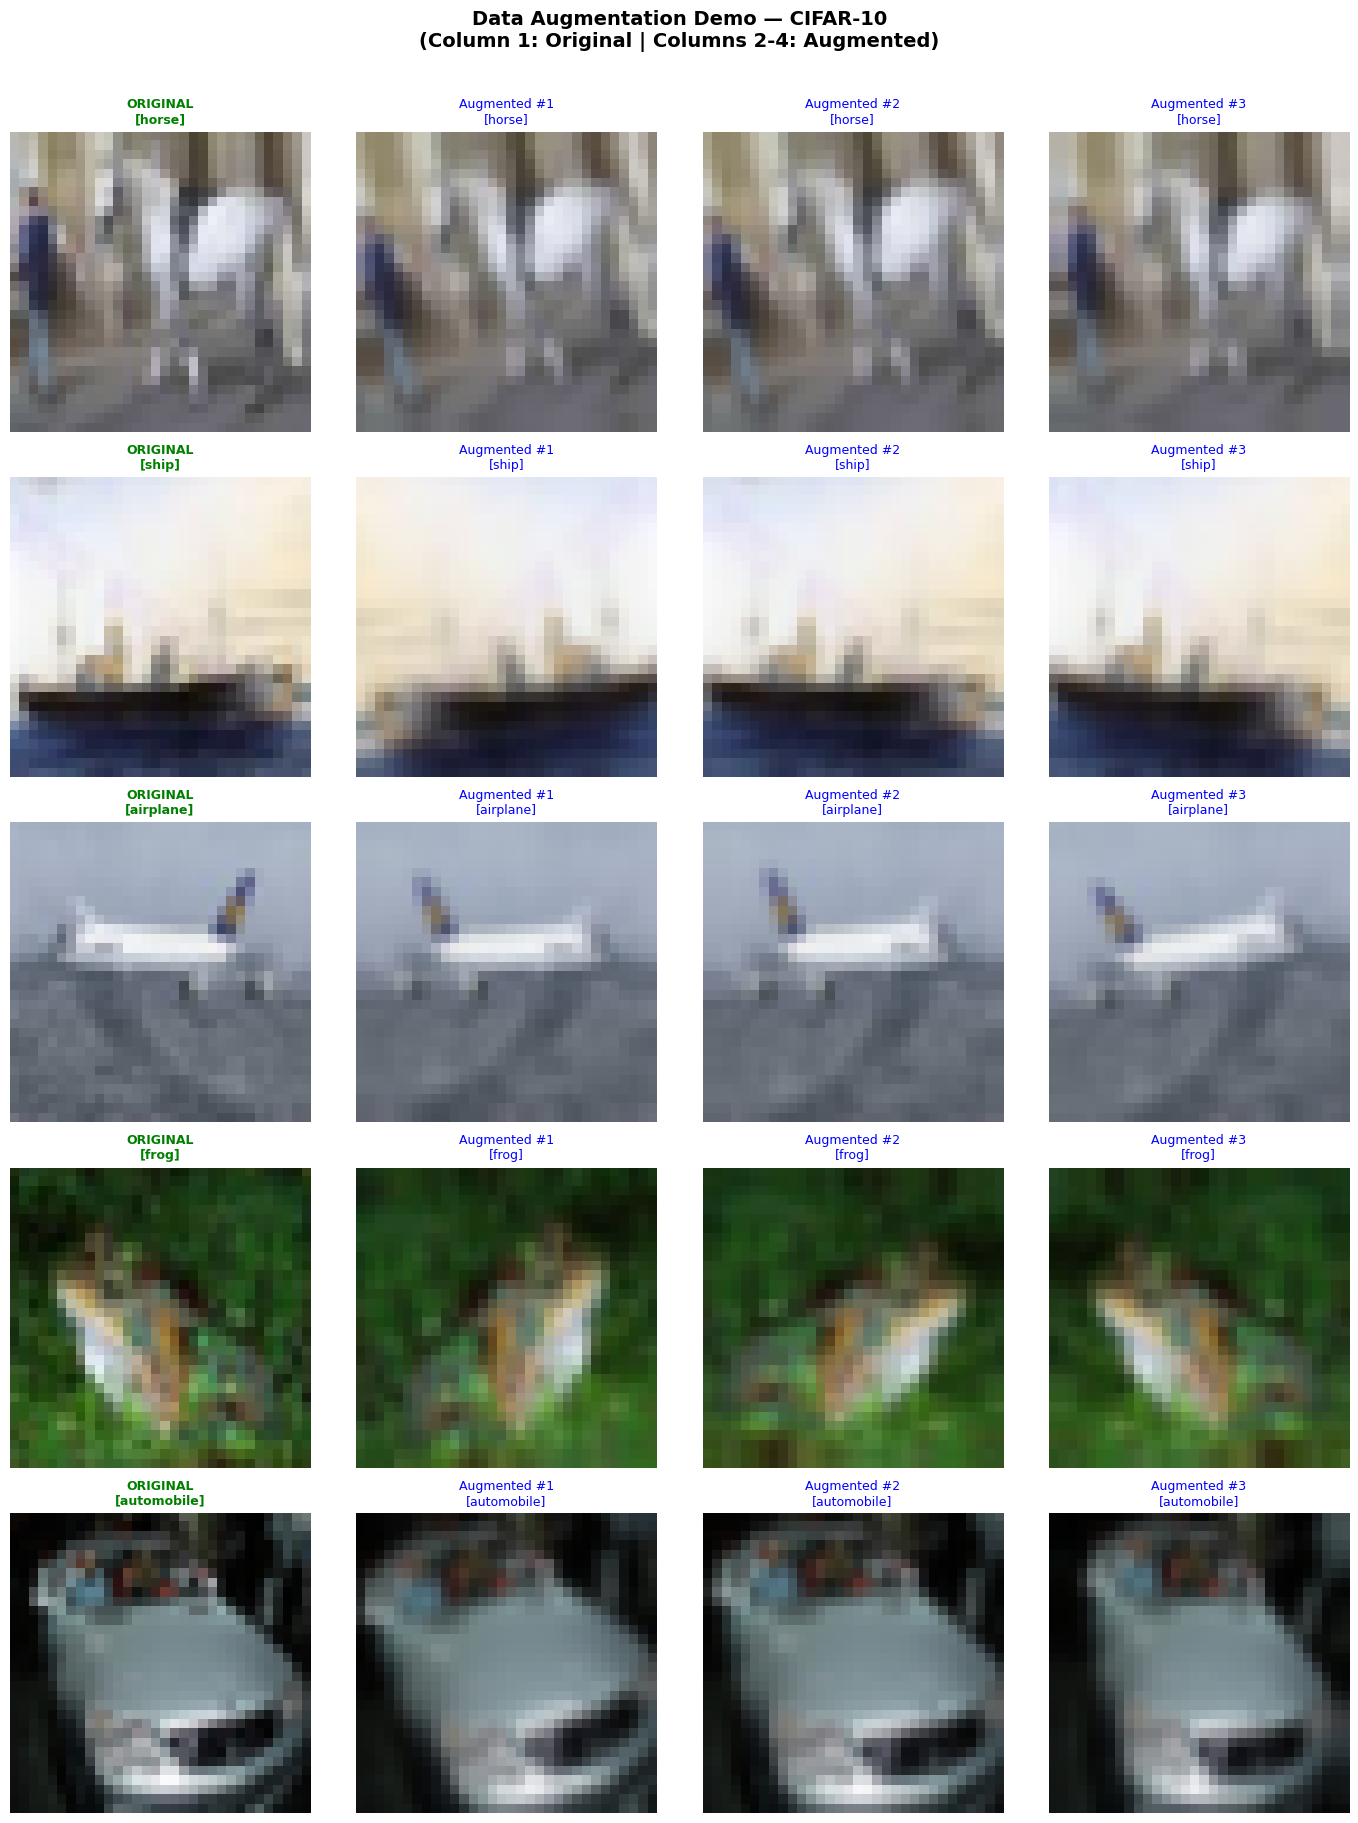


WHY AUGMENTATION IS ONLY FOR TRAINING — NOT VALIDATION/TEST

JUSTIFICATION:

1. PURPOSE OF AUGMENTATION:
   Augmentation artificially increases the variety of training data.
   It teaches the model to recognize objects even when they are
   flipped, rotated, or zoomed — making the model more ROBUST.

2. WHY NOT ON VALIDATION OR TEST SET:
   The validation and test sets are used to MEASURE how well the
   model performs on real-world, unseen data.

   If we augment these sets:
   → The images no longer look like real-world inputs.
   → Our accuracy score becomes unreliable and misleading.
   → We can't trust whether the model is actually learning or not.

   Think of it like an EXAM:
   → Training = practice at home (you can vary the questions)
   → Test/Validation = the real exam (must be consistent & fair)
   Changing the exam questions each time makes results meaningless.

3. CONSISTENCY MATTERS:
   Test images must always be the SAME so we can compare results
   across different mo

In [8]:
# ============================================================
# PROBLEM 4: Data Augmentation Pipeline
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# STEP 1: Load and Normalize CIFAR-10
# ============================================================
(cifar_x_train, cifar_y_train), (_, _) = cifar10.load_data()

# Normalize to [0.0, 1.0]
cifar_x_train = cifar_x_train.astype('float32') / 255.0

cifar_class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("CIFAR-10 loaded and normalized!")
print(f"Shape: {cifar_x_train.shape}\n")

# ============================================================
# STEP 2: Build the Augmentation Pipeline
# ============================================================

# We use Keras built-in augmentation layers (no GPU needed)
# Each layer applies a random transformation every time it's called

augmentation_pipeline = tf.keras.Sequential([

    # (a) Horizontal Flip with probability 0.5
    # Randomly flips the image left-right, 50% of the time
    # WHY it's safe for CIFAR-10: A flipped airplane is still an airplane,
    # a flipped car is still a car. Labels don't change.
    # WHY NOT for MNIST: A flipped '6' looks like '9' → label would be WRONG!
    layers.RandomFlip("horizontal"),

    # (b) Random Rotation in range ±10 degrees
    # Rotates the image by a random angle between -10 and +10 degrees
    # factor=0.1 means 10% of 360 degrees = ±36 degrees MAX
    # But we want ±10 degrees, so factor = 10/360 ≈ 0.028
    layers.RandomRotation(factor=0.028),

    # (c) Random Zoom of up to 10%
    # Zooms in or out randomly by up to 10%
    # height_factor=0.1 means zoom by up to 10%
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),

], name="augmentation_pipeline")

print("Augmentation pipeline built!")
print("  (a) Horizontal Flip  → probability 0.5")
print("  (b) Random Rotation  → ±10 degrees")
print("  (c) Random Zoom      → up to 10%\n")

# ============================================================
# STEP 3: Pick 5 random CIFAR-10 images
# ============================================================
random_indexes = np.random.choice(len(cifar_x_train), 5, replace=False)

selected_images = cifar_x_train[random_indexes]
selected_labels = cifar_y_train[random_indexes].flatten()

print("Selected 5 random images:")
for i, idx in enumerate(random_indexes):
    print(f"  Image {i+1}: index {idx} → class '{cifar_class_names[selected_labels[i]]}'")

# ============================================================
# STEP 4: Apply augmentation and create 5x4 grid
# ============================================================

# The grid has:
# - 5 rows    → one row per image
# - 4 columns → col 0 = original, col 1/2/3 = 3 augmented versions

fig, axes = plt.subplots(5, 4, figsize=(14, 18))

fig.suptitle("Data Augmentation Demo — CIFAR-10\n(Column 1: Original | Columns 2-4: Augmented)",
             fontsize=14, fontweight='bold', y=1.01)

for row in range(5):

    original_image = selected_images[row]         # shape: (32, 32, 3)
    label_name     = cifar_class_names[selected_labels[row]]

    # --- COLUMN 0: Original image ---
    axes[row, 0].imshow(original_image)
    axes[row, 0].set_title(f"ORIGINAL\n[{label_name}]", fontsize=9, fontweight='bold', color='green')
    axes[row, 0].axis('off')

    # --- COLUMNS 1, 2, 3: Three different augmented versions ---
    for col in range(1, 4):

        # Add batch dimension: (32, 32, 3) → (1, 32, 32, 3)
        # Keras augmentation layers expect a BATCH of images, not a single image
        image_batch = tf.expand_dims(original_image, axis=0)

        # Apply augmentation — each call gives a DIFFERENT random result
        augmented_batch = augmentation_pipeline(image_batch, training=True)
        # training=True is IMPORTANT — augmentation only runs when training=True
        # If training=False, the image passes through unchanged

        # Remove batch dimension: (1, 32, 32, 3) → (32, 32, 3)
        augmented_image = augmented_batch[0].numpy()

        # Clip values to [0, 1] just in case augmentation pushed values slightly out
        augmented_image = np.clip(augmented_image, 0.0, 1.0)

        axes[row, col].imshow(augmented_image)
        axes[row, col].set_title(f"Augmented #{col}\n[{label_name}]", fontsize=9, color='blue')
        axes[row, col].axis('off')

# Add row labels on the left side
for row in range(5):
    axes[row, 0].set_ylabel(f"Image {row+1}", fontsize=11,
                             fontweight='bold', rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=150, bbox_inches='tight')
print("\nFigure saved as: augmentation_demo.png ✅")
plt.show()


# ============================================================
# STEP 5: Written Justification (also printed as output)
# ============================================================
print("\n" + "=" * 60)
print("WHY AUGMENTATION IS ONLY FOR TRAINING — NOT VALIDATION/TEST")
print("=" * 60)

justification = """
JUSTIFICATION:

1. PURPOSE OF AUGMENTATION:
   Augmentation artificially increases the variety of training data.
   It teaches the model to recognize objects even when they are
   flipped, rotated, or zoomed — making the model more ROBUST.

2. WHY NOT ON VALIDATION OR TEST SET:
   The validation and test sets are used to MEASURE how well the
   model performs on real-world, unseen data.

   If we augment these sets:
   → The images no longer look like real-world inputs.
   → Our accuracy score becomes unreliable and misleading.
   → We can't trust whether the model is actually learning or not.

   Think of it like an EXAM:
   → Training = practice at home (you can vary the questions)
   → Test/Validation = the real exam (must be consistent & fair)
   Changing the exam questions each time makes results meaningless.

3. CONSISTENCY MATTERS:
   Test images must always be the SAME so we can compare results
   across different models and training runs fairly.

4. LABEL PRESERVATION (which augmentations are safe for CIFAR-10):
   ✅ Horizontal Flip  → A flipped car/airplane still looks correct
   ✅ Rotation ±10°   → A slightly rotated dog is still a dog
   ✅ Zoom up to 10%  → A zoomed-in cat is still a cat

   ❌ Horizontal Flip on MNIST → '6' flipped looks like '9' (WRONG label!)
   ❌ Large rotation on digits → '9' rotated 180° looks like '6' (WRONG!)

   So augmentation must only use transformations that PRESERVE
   the true meaning/label of the image.
"""

print(justification)

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference to
both a greyscale image and an RGB image.
Ans. The shape (N, H, W, C) represents a batch of images where N = number of images, H = height in pixels, W = width in pixels, and C = number of channels. The channel dimension tells us how many types of information each pixel holds. For a greyscale image (like MNIST), C = 1 because each pixel only stores one value — its brightness (0 to 255). For an RGB image (like CIFAR-10), C = 3 because each pixel stores three values — Red, Green, and Blue — which combine to form any colour. This is why we reshaped MNIST from (N, 28, 28) to (N, 28, 28, 1) in preprocessing — to explicitly tell the CNN that there is 1 channel, since CNNs require the channel dimension to be present in order to apply their filters correctly.

Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what
data loading strategies would you use to avoid running out of memory? Name at least two techniques and
explain how each one helps.
Ans. When working with large images like 1024×1024 satellite images, loading the entire dataset into RAM at once would crash your system. The two main strategies to handle this are Data Generators and Mixed Precision Training. A Data Generator (like Keras's ImageDataGenerator or tf.data.Dataset) loads images in small batches on-the-fly instead of all at once — so instead of loading 50,000 huge images into memory, you only load 32 at a time, process them, and then discard them before loading the next batch. This keeps memory usage small and constant no matter how large the dataset is. The second technique is Image Patching, where instead of feeding the full 1024×1024 image into the CNN, you cut it into smaller patches (e.g., 128×128 or 256×256) and train on those patches — this drastically reduces the size of each input and allows the model to still learn features without needing massive memory. Together, these two techniques allow you to train on very large images even on a machine with limited RAM or no GPU.

Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation
computed from the test set itself. What is wrong with this approach?
Ans.this approach?7:29 PMThis is a form of data leakage. The test set is supposed to simulate completely unseen, real-world data — the model should never have any information from it during training or preprocessing. When you compute the mean and standard deviation from the test set itself and use those values to normalise it, you are allowing information from the test set to influence the preprocessing, which makes the evaluation unfair and unreliable. The correct approach is to compute the mean and standard deviation only from the training set, and then apply those exact same values to normalise both the validation and test sets. This way, the test set is treated as if it truly came from the outside world — the model and all preprocessing steps remain completely blind to it, and the accuracy score you get is a honest reflection of real-world performance.

TASK 2


In [9]:
# ============================================================
# PROBLEM 1: Manual 2D Convolution (NumPy only)
# ============================================================

import numpy as np

np.random.seed(42)

# ============================================================
# STEP 1: Define the conv2d function
# ============================================================

def conv2d(image, kernel, stride=1, padding=0):
    """
    Performs 2D convolution manually using only NumPy.

    Parameters:
      image   : 2D numpy array (the input image)
      kernel  : 2D numpy array (the filter)
      stride  : how many pixels to move the kernel each step
      padding : how many zeros to add around the image border

    Returns:
      feature_map : 2D numpy array (the output)
    """

    # ----------------------------------------------------------
    # PART (a): Get sizes of image and kernel
    # ----------------------------------------------------------
    image_h, image_w   = image.shape     # image height and width
    kernel_h, kernel_w = kernel.shape    # kernel height and width

    # ----------------------------------------------------------
    # PART (b): Apply zero-padding if needed
    # ----------------------------------------------------------
    if padding > 0:
        # np.pad adds zeros around the image border
        # (padding, padding) means add 'padding' zeros on EACH side
        image = np.pad(image,
                       pad_width=((padding, padding), (padding, padding)),
                       mode='constant',
                       constant_values=0)
        print(f"  Padding applied: {padding} zero(s) added on each side")
        print(f"  Image shape after padding: {image.shape}")

    # ----------------------------------------------------------
    # Calculate output size using the formula:
    # output_size = (input_size - kernel_size + 2*padding) / stride + 1
    # ----------------------------------------------------------
    output_h = int((image_h - kernel_h + 2 * padding) / stride) + 1
    output_w = int((image_w - kernel_w + 2 * padding) / stride) + 1

    print(f"\n  Output size formula:")
    print(f"  output_h = ({image_h} - {kernel_h} + 2*{padding}) / {stride} + 1 = {output_h}")
    print(f"  output_w = ({image_w} - {kernel_w} + 2*{padding}) / {stride} + 1 = {output_w}")

    # Create an empty output array filled with zeros
    feature_map = np.zeros((output_h, output_w))

    # ----------------------------------------------------------
    # PART (c): Slide the kernel across the image
    # ----------------------------------------------------------
    # We use nested for-loops:
    # - Outer loop moves DOWN  the image (rows)
    # - Inner loop moves ACROSS the image (columns)

    for row in range(output_h):
        for col in range(output_w):

            # Calculate where the kernel window starts in the image
            row_start = row * stride
            row_end   = row_start + kernel_h

            col_start = col * stride
            col_end   = col_start + kernel_w

            # Extract the patch (small piece of image under the kernel)
            patch = image[row_start:row_end, col_start:col_end]

            # Element-wise multiply patch by kernel, then sum all values
            # This is the core convolution operation
            feature_map[row, col] = np.sum(patch * kernel)

            # Example of what happens:
            # patch = [[3,1,0],    kernel = [[-1,0,1],
            #          [1,5,3],              [-2,0,2],
            #          [0,2,6]]              [-1,0,1]]
            #
            # multiply element by element:
            # [[-3,0,0], [-2,0,6], [0,0,6]]
            # sum all = 7  → this goes into feature_map[row, col]

    return feature_map


# ============================================================
# STEP 2: Define the test image and Sobel-X kernel
# ============================================================

# 5×5 test image (given in the problem)
image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
], dtype=float)

# Sobel-X kernel (detects vertical edges / horizontal changes)
# Negative on left → positive on right
# This highlights places where brightness changes left-to-right
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

print("=" * 50)
print("INPUT IMAGE (5×5):")
print("=" * 50)
print(image)

print("\nSOBEL-X KERNEL (3×3):")
print(kernel)

# ============================================================
# STEP 3: Run the convolution
# ============================================================
print("\n" + "=" * 50)
print("RUNNING CONVOLUTION (stride=1, padding=0)")
print("=" * 50)

feature_map = conv2d(image, kernel, stride=1, padding=0)

# ============================================================
# STEP 4: Print the output
# ============================================================
print("\n" + "=" * 50)
print("OUTPUT FEATURE MAP:")
print("=" * 50)
print(feature_map)

print("\n" + "=" * 50)
print("SHAPE VERIFICATION")
print("=" * 50)
print(f"Input image shape  : {image.shape}  → (5 × 5)")
print(f"Kernel shape       : {kernel.shape}  → (3 × 3)")
print(f"Stride             : 1")
print(f"Padding            : 0")
print(f"\nFormula: output = (input - kernel + 2×padding) / stride + 1")
print(f"       = (5 - 3 + 2×0) / 1 + 1")
print(f"       = (2) / 1 + 1")
print(f"       = 3 + 0 = 3")
print(f"\nExpected output shape : (3 × 3)")
print(f"Actual output shape   : {feature_map.shape}")

if feature_map.shape == (3, 3):
    print("\nShape verification PASSED ✅")
else:
    print("\nShape verification FAILED ❌")

# ============================================================
# STEP 5: What does the Sobel-X output tell us?
# ============================================================
print("\n" + "=" * 50)
print("WHAT DOES THE OUTPUT MEAN?")
print("=" * 50)
print("""
The Sobel-X kernel detects VERTICAL EDGES in the image.
It looks for places where pixel brightness changes LEFT to RIGHT.

  Positive values → brightness increases left to right (light edge)
  Negative values → brightness decreases left to right (dark edge)
  Near zero       → no strong horizontal change (flat region)

The output feature map highlights WHERE these edges are in the image.
This is exactly what the first layers of a CNN do automatically —
they learn kernels (filters) that detect edges, corners, and patterns.
""")

INPUT IMAGE (5×5):
[[3. 1. 0. 2. 4.]
 [1. 5. 3. 2. 1.]
 [0. 2. 6. 4. 3.]
 [2. 3. 1. 5. 2.]
 [1. 0. 2. 3. 4.]]

SOBEL-X KERNEL (3×3):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

RUNNING CONVOLUTION (stride=1, padding=0)

  Output size formula:
  output_h = (5 - 3 + 2*0) / 1 + 1 = 3
  output_w = (5 - 3 + 2*0) / 1 + 1 = 3

OUTPUT FEATURE MAP:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

SHAPE VERIFICATION
Input image shape  : (5, 5)  → (5 × 5)
Kernel shape       : (3, 3)  → (3 × 3)
Stride             : 1
Padding            : 0

Formula: output = (input - kernel + 2×padding) / stride + 1
       = (5 - 3 + 2×0) / 1 + 1
       = (2) / 1 + 1
       = 3 + 0 = 3

Expected output shape : (3 × 3)
Actual output shape   : (3, 3)

Shape verification PASSED ✅

WHAT DOES THE OUTPUT MEAN?

The Sobel-X kernel detects VERTICAL EDGES in the image.
It looks for places where pixel brightness changes LEFT to RIGHT.

  Positive values → brightness increases left to right (light edge)
  Negative values → 